# 🚀 GNN-Based Data Locality Optimization

## Final Results & Demonstration

**Author:** Oussama Lakhili  
**Date:** September 2026

This notebook presents the final results of the heterogeneous Graph Neural Network trained to optimize data locality in a simulated Hadoop/Spark cluster.

**Key results:** F1-score 95.87%, Accuracy 97.77%

In [2]:
# ============================================
# IMPORTS AND PATH SETUP
# ============================================

import sys
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Locate the src directory robustly ---
# This works whether the notebook is run from the project root or notebooks/ folder
if os.path.exists('../src'):
    src_path = os.path.abspath('../src')
elif os.path.exists('src'):
    src_path = os.path.abspath('src')
else:
    raise FileNotFoundError("Could not locate src directory. Please run this notebook from the project root or notebooks folder.")

project_root = os.path.dirname(src_path)  # parent of src is the project root
sys.path.insert(0, src_path)

from graph_builder import GraphBuilder
from gnn_model import HeterogeneousGNN
from trainer import prepare_graph_data, safe_torch_load, resolve_device

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports successful")
print(f"Project root: {project_root}")

c:\Users\HP\Desktop\projects\gnn-data-locality-optimizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful
Project root: c:\Users\HP\Desktop\projects\gnn-data-locality-optimizer


In [3]:
# ============================================
# LOAD GRAPH AND TRAINED MODEL
# ============================================

device = resolve_device("auto")
print(f"Using device: {device}")

graph_path = os.path.join(project_root, "data", "graphs", "graph.pt")
checkpoint_path = os.path.join(project_root, "data", "models", "best_model.pt")

# Load graph
graph = safe_torch_load(graph_path, map_location="cpu")

# Load checkpoint
checkpoint = safe_torch_load(checkpoint_path, map_location=device)

# Rebuild model architecture
model_cfg = checkpoint.get("model_config", {})
model = HeterogeneousGNN(
    hidden_channels=model_cfg.get("hidden_channels", 64),
    num_layers=model_cfg.get("num_layers", 3),
    dropout=model_cfg.get("dropout", 0.3),
).to(device)

model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
model.eval()

print("Graph and model loaded successfully")

INFO:gnn_model:Initialized HeterogeneousGNN with 3 layers and 64 hidden channels.


Using device: cpu
Graph and model loaded successfully


In [4]:
# ============================================
# LOAD GRAPH AND TRAINED MODEL
# ============================================

device = resolve_device("auto")
print(f"Using device: {device}")

graph_path = os.path.join(project_root, "data", "graphs", "graph.pt")
checkpoint_path = os.path.join(project_root, "data", "models", "best_model.pt")

# Load graph
graph = safe_torch_load(graph_path, map_location="cpu")

# Load checkpoint
checkpoint = safe_torch_load(checkpoint_path, map_location=device)

# Rebuild model architecture
model_cfg = checkpoint.get("model_config", {})
model = HeterogeneousGNN(
    hidden_channels=model_cfg.get("hidden_channels", 64),
    num_layers=model_cfg.get("num_layers", 3),
    dropout=model_cfg.get("dropout", 0.3),
).to(device)

model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
model.eval()

print("Graph and model loaded successfully")

INFO:gnn_model:Initialized HeterogeneousGNN with 3 layers and 64 hidden channels.


Using device: cpu
Graph and model loaded successfully


In [5]:
# ============================================
# PREPARE DATA AND RUN INFERENCE
# ============================================

data = prepare_graph_data(graph, device)

# Retrieve test mask from checkpoint if available
split_masks = checkpoint.get("split_masks")
if split_masks:
    test_mask = split_masks.get("test")
    if test_mask is not None:
        test_mask = test_mask.to(device)
else:
    test_mask = torch.ones(data["edge_labels"].numel(), dtype=torch.bool, device=device)

with torch.no_grad():
    embeddings = model(data["x_dict"], data["edge_index_dict"])
    logits = model.predict_edge_labels(embeddings, data["edge_index"])
    probabilities = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    predictions = logits.argmax(dim=-1).cpu().numpy()

true_labels = data["edge_labels"].cpu().numpy()
test_true = true_labels[test_mask.cpu().numpy()]
test_pred = predictions[test_mask.cpu().numpy()]
test_prob = probabilities[test_mask.cpu().numpy()]

print(f"Number of test edges: {len(test_true)}")
print(f"True positive rate (actual locality): {test_true.mean():.2%}")
print(f"Predicted positive rate: {test_pred.mean():.2%}")

Number of test edges: 448
True positive rate (actual locality): 26.34%
Predicted positive rate: 27.68%


In [6]:
# ============================================
# CLASSIFICATION METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(test_true, test_pred)
precision = precision_score(test_true, test_pred, zero_division=0)
recall = recall_score(test_true, test_pred, zero_division=0)
f1 = f1_score(test_true, test_pred, zero_division=0)

print("=" * 40)
print("TEST SET PERFORMANCE")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("=" * 40)

# Display classification report
print("\nClassification Report:")
print(classification_report(test_true, test_pred, target_names=["Remote", "Local"]))

TEST SET PERFORMANCE
Accuracy : 0.9777
Precision: 0.9355
Recall   : 0.9831
F1-score : 0.9587

Classification Report:
              precision    recall  f1-score   support

      Remote       0.99      0.98      0.98       330
       Local       0.94      0.98      0.96       118

    accuracy                           0.98       448
   macro avg       0.96      0.98      0.97       448
weighted avg       0.98      0.98      0.98       448



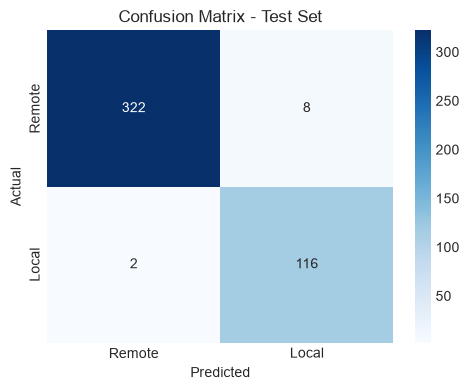

In [7]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Remote", "Local"],
            yticklabels=["Remote", "Local"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

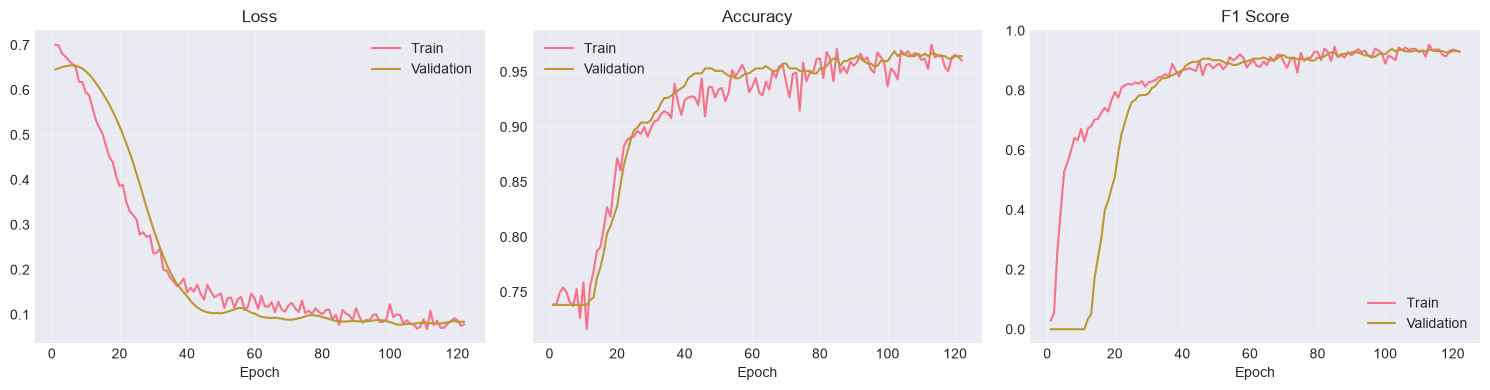

In [8]:
# ============================================
# LEARNING CURVES
# ============================================

history_path = os.path.join(project_root, "data", "models", "training_history.json")
with open(history_path, "r", encoding="utf-8") as f:
    history = json.load(f)

hist_data = history.get("history", history)
epochs = hist_data.get("epoch", [])
train_loss = hist_data.get("train_loss", [])
val_loss = hist_data.get("val_loss", [])
train_acc = hist_data.get("train_accuracy", [])
val_acc = hist_data.get("val_accuracy", [])
train_f1 = hist_data.get("train_f1", [])
val_f1 = hist_data.get("val_f1", [])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_loss, label="Train")
axes[0].plot(epochs, val_loss, label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_acc, label="Train")
axes[1].plot(epochs, val_acc, label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, train_f1, label="Train")
axes[2].plot(epochs, val_f1, label="Validation")
axes[2].set_title("F1 Score")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

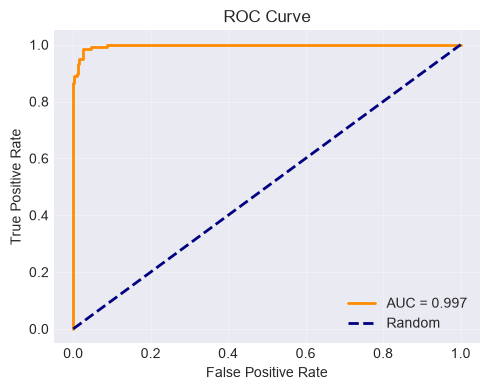

In [9]:
# ============================================
# ROC CURVE
# ============================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The heterogeneous GraphSAGE model successfully learned to classify data block placements as local or remote. With an F1-score of **95.87%**, it can reliably identify suboptimal placements and guide data reorganization to improve data locality in the cluster.